In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx
from itertools import combinations

In [2]:
df = pd.read_csv('../DATA/02_image_clusters/full_image_data_feb_25.csv')
books = pd.read_csv('../DATA/01_corpus_metadata/full_book_data_feb_25.csv')

In [3]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

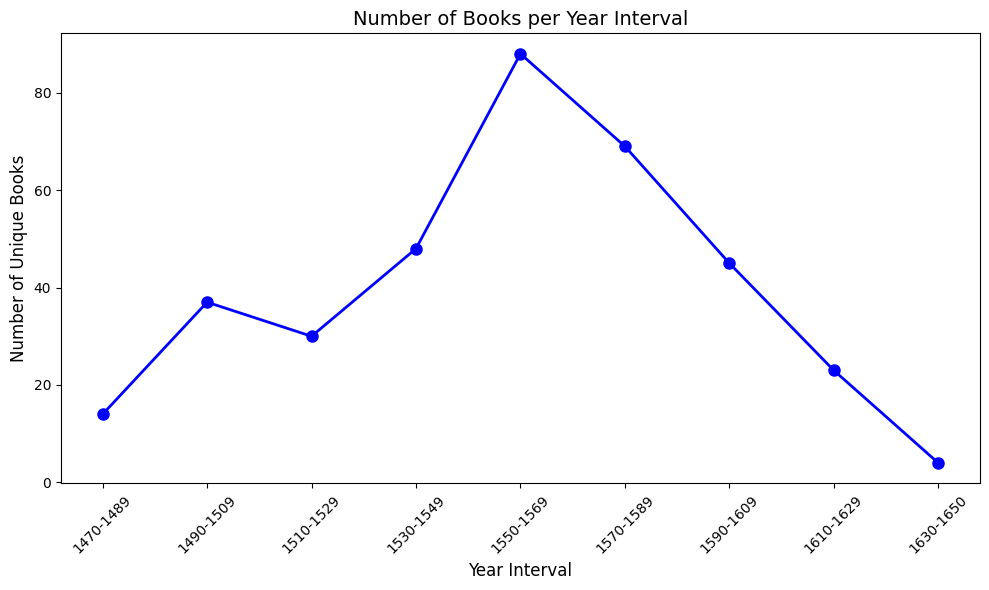

In [4]:

# Group by 'year_interval' and count the unique books
unique_books_per_interval = books.groupby('year_interval')['book'].nunique()

# Ensure the intervals are ordered correctly based on the 'year_interval' in your data
ordered_intervals = pd.Categorical(unique_books_per_interval.index, ordered=True)

# Reorder the Series by the correct order of 'year_interval'
unique_books_per_interval = unique_books_per_interval[ordered_intervals]

# Plot the result
plt.figure(figsize=(10, 6))
plt.plot(unique_books_per_interval.index, unique_books_per_interval, marker='o', color='b', linestyle='-', linewidth=2, markersize=8)

# Improve the plot (labels, title, etc.)
plt.title('Number of Books per Year Interval', fontsize=14)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Number of Unique Books', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()  # Adjust layout to avoid clipping of labels

# Show the plot
plt.show()


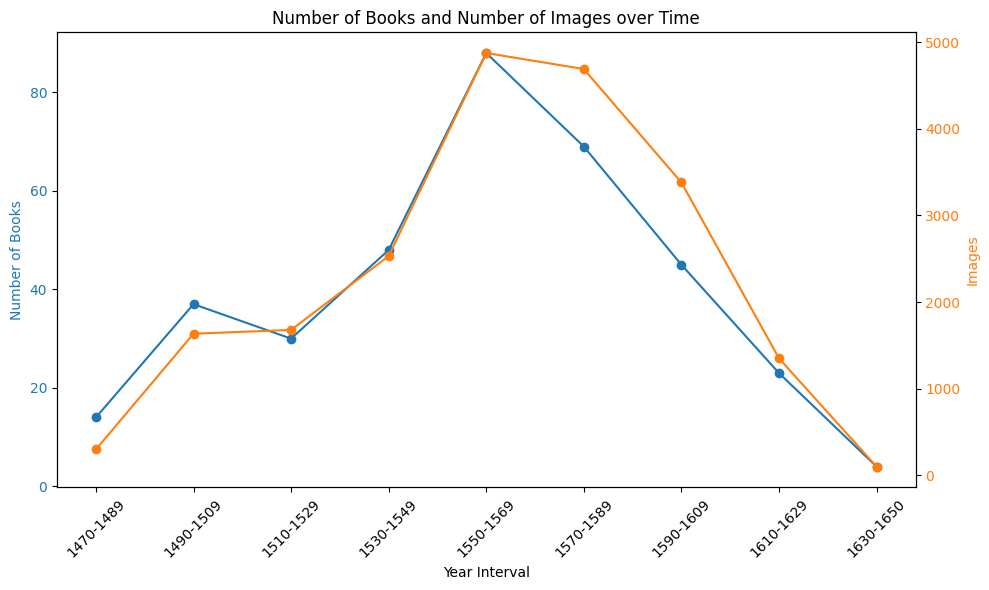

In [5]:

# Line 1: Number of unique book values per interval in books
book_counts = books.groupby('year_interval', observed=False)['book'].nunique()

# Line 2: Number of unique image values per interval in df
image_counts = df.groupby('year_interval', observed=False)['images'].nunique()

# Create the plot with two Y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot the first line (unique books) on the left Y-axis
ax1.plot(book_counts.index, book_counts.values, label='Unique Books', marker='o', color='tab:blue')
ax1.set_xlabel('Year Interval')
ax1.set_ylabel('Number of Books', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Create a second Y-axis to plot unique images
ax2 = ax1.twinx()  
ax2.plot(image_counts.index, image_counts.values, label='Images', marker='o', color='tab:orange')
ax2.set_ylabel('Images', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Customize the plot
plt.title('Number of Books and Number of Images over Time')

# Adjust x-axis labels to show rotated years without the warning
ax1.set_xticks(range(len(book_counts.index)))  # Set the tick positions
ax1.set_xticklabels(book_counts.index, rotation=45)  # Set the labels

fig.tight_layout()

# Show the plot
plt.show()


               Unique Books  Unique Images  Average Images per Book
year_interval                                                      
1470-1489                11            300                27.272727
1490-1509                36           1635                45.416667
1510-1529                30           1679                55.966667
1530-1549                47           2531                53.851064
1550-1569                87           4874                56.022989
1570-1589                62           4689                75.629032
1590-1609                45           3380                75.111111
1610-1629                20           1351                67.550000
1630-1650                 4            101                25.250000


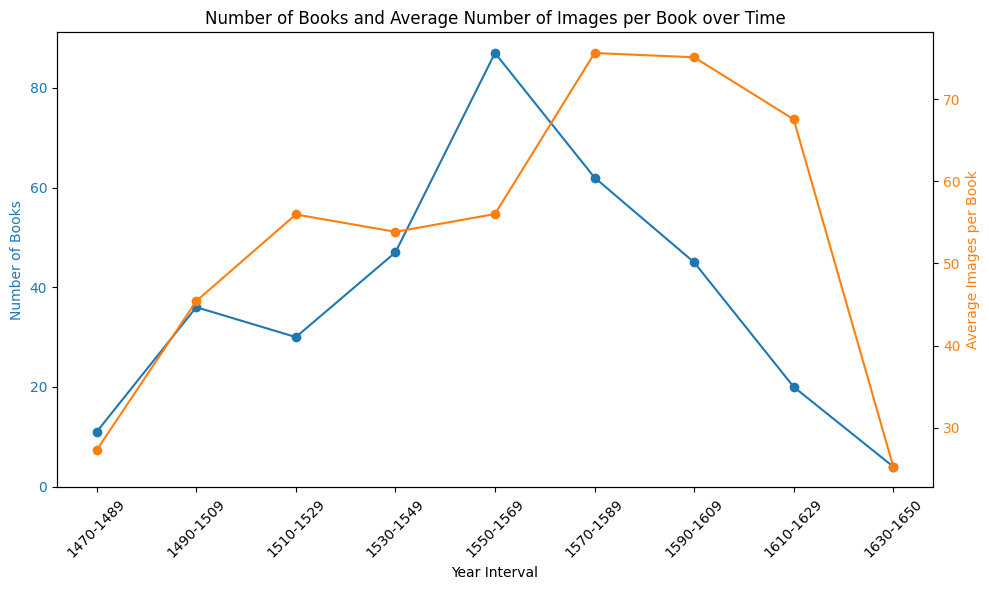

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: count unique books and unique images per year_interval ---
book_counts = df.groupby('year_interval')['book'].nunique()
image_counts = df.groupby('year_interval')['images'].nunique()

# --- Step 2: calculate average images per book ---
avg_images_per_book = (image_counts / book_counts).replace([float('inf'), float('nan')], 0)

# --- Step 3: create a simple dataframe to show the results ---
summary_df = pd.DataFrame({
    'Unique Books': book_counts,
    'Unique Images': image_counts,
    'Average Images per Book': avg_images_per_book
})

print(summary_df)

# --- Step 4: plot ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Number of books
ax1.plot(summary_df.index, summary_df['Unique Books'], label='Number of Books', color='tab:blue', marker='o')
ax1.set_xlabel('Year Interval')
ax1.set_ylabel('Number of Books', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Average images per book
ax2 = ax1.twinx()
ax2.plot(summary_df.index, summary_df['Average Images per Book'], label='Average Images per Book', color='tab:orange', marker='o')
ax2.set_ylabel('Average Images per Book', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# Title and formatting
plt.title('Number of Books and Average Number of Images per Book over Time')
ax1.set_xticks(range(len(summary_df.index)))
ax1.set_xticklabels(summary_df.index, rotation=45)
fig.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/ave_image_book.png', dpi=300, bbox_inches='tight')

plt.show()


               Unique Books  Average Images per Book
year_interval                                       
1470-1489                11                27.272727
1490-1509                36                45.416667
1510-1529                30                55.966667
1530-1549                47                53.851064
1550-1569                87                56.022989
1570-1589                62                75.629032
1590-1609                45                75.111111
1610-1629                20                67.550000
1630-1650                 4                25.250000


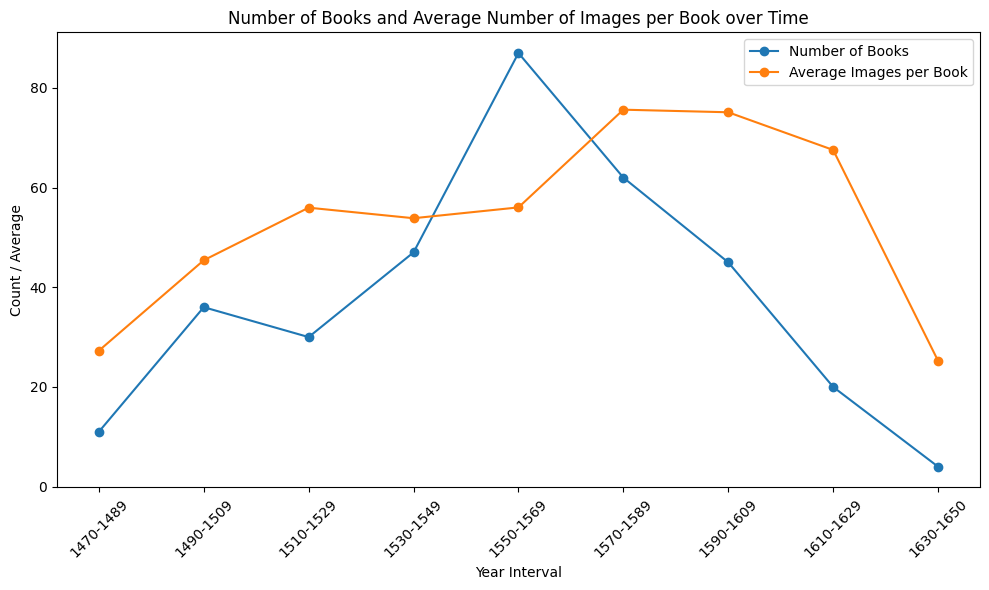

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: count unique books and images per year_interval ---
book_counts = df.groupby('year_interval')['book'].nunique()
image_counts = df.groupby('year_interval')['images'].nunique()

# --- Step 2: calculate average images per book ---
avg_images_per_book = (image_counts / book_counts).replace([float('inf'), float('nan')], 0)

# --- Step 3: create a summary dataframe ---
summary_df = pd.DataFrame({
    'Unique Books': book_counts,
    'Average Images per Book': avg_images_per_book
})

print(summary_df)

# --- Step 4: plot both lines on the same scale ---
plt.figure(figsize=(10, 6))
plt.plot(summary_df.index, summary_df['Unique Books'], label='Number of Books', marker='o', color='tab:blue')
plt.plot(summary_df.index, summary_df['Average Images per Book'], label='Average Images per Book', marker='o', color='tab:orange')

plt.xlabel('Year Interval')
plt.ylabel('Count / Average')
plt.title('Number of Books and Average Number of Images per Book over Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


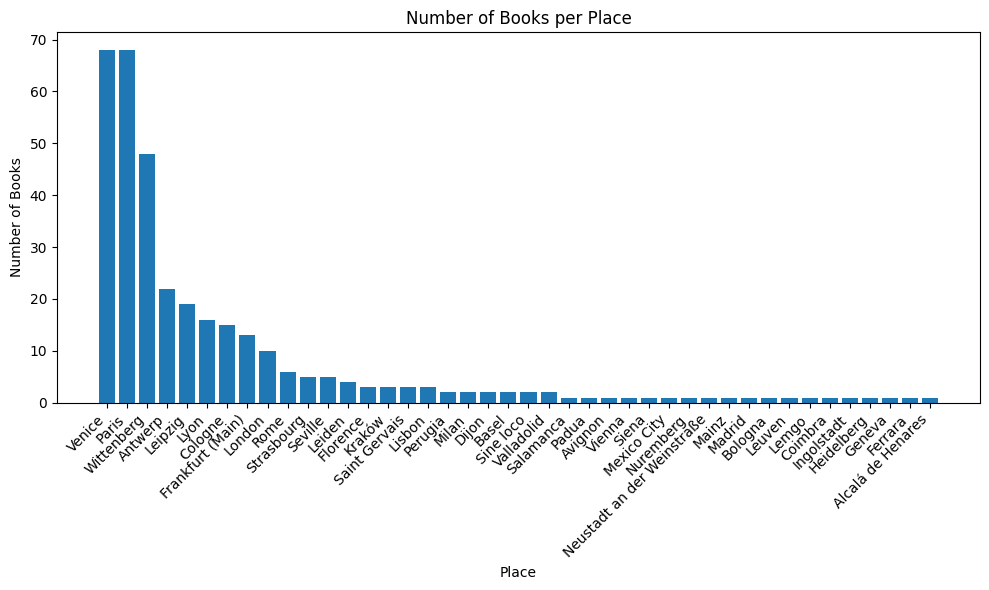

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: count unique books per place ---
books_per_place = df.groupby('place')['book'].nunique()

# --- Step 2: sort descending so the largest is first ---
books_per_place = books_per_place.sort_values(ascending=False)

# --- Step 3: plot ---
plt.figure(figsize=(10, 6))
plt.bar(books_per_place.index, books_per_place.values, color='tab:blue')

plt.xlabel('Place')
plt.ylabel('Number of Books')
plt.title('Number of Books per Place')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


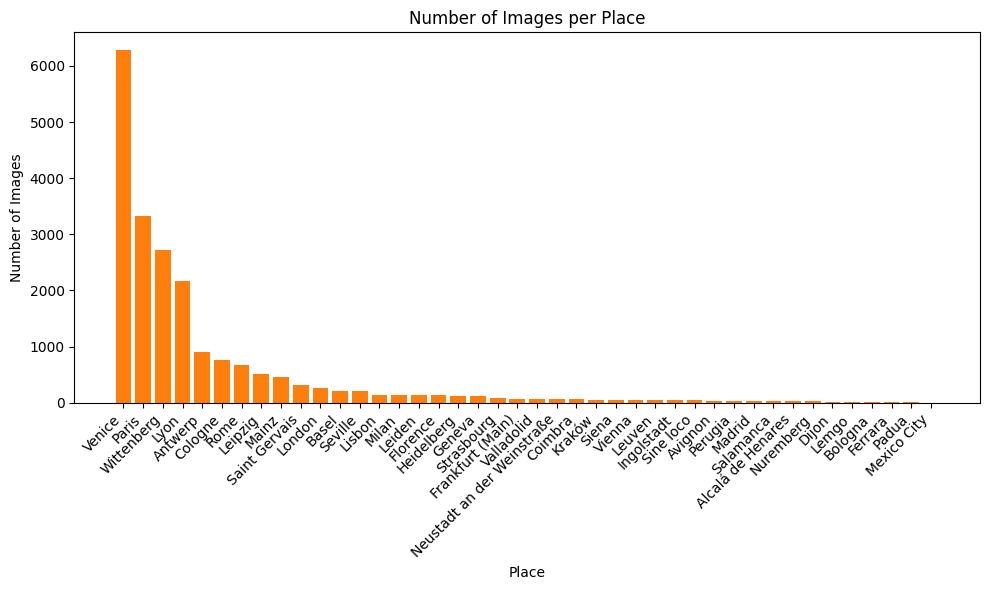

In [13]:
# --- Step 1: count unique images per place ---
images_per_place = df.groupby('place')['images'].nunique()

# --- Step 2: sort descending ---
images_per_place = images_per_place.sort_values(ascending=False)

# --- Step 3: plot ---
plt.figure(figsize=(10, 6))
plt.bar(images_per_place.index, images_per_place.values, color='tab:orange')

plt.xlabel('Place')
plt.ylabel('Number of Images')
plt.title('Number of Images per Place')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


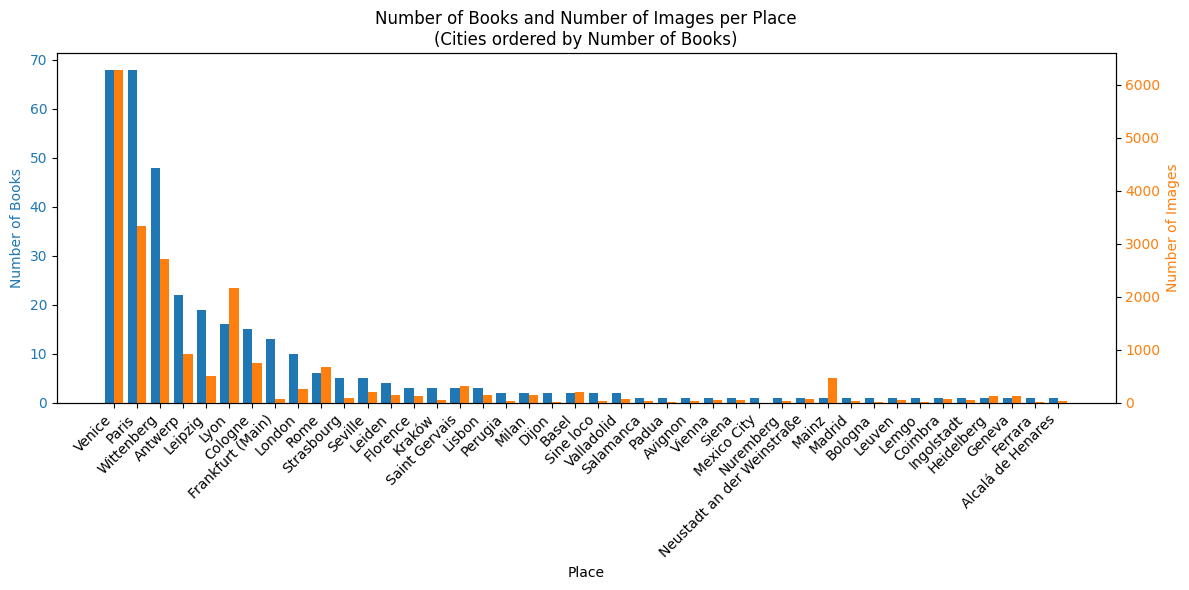

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Count unique books and images per place ---
books_per_place = df.groupby('place')['book'].nunique()
images_per_place = df.groupby('place')['images'].nunique()

# --- Step 2: Sort places by number of books descending ---
places_sorted = books_per_place.sort_values(ascending=False).index
books_sorted = books_per_place[places_sorted]
images_sorted = images_per_place.reindex(places_sorted)  # align images to same order

# --- Step 3: Prepare the x positions ---
x = np.arange(len(places_sorted))
width = 0.4  # width of the bars

# --- Step 4: Plot the bars ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Y-axis: Number of Books
bars1 = ax1.bar(x - width/2, books_sorted.values, width, color='tab:blue')
ax1.set_ylabel('Number of Books', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right Y-axis: Number of Images
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, images_sorted.values, width, color='tab:orange')
ax2.set_ylabel('Number of Images', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# X-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(places_sorted, rotation=45, ha='right')
ax1.set_xlabel('Place')
plt.title('Number of Books and Number of Images per Place\n(Cities ordered by Number of Books)')

plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/place_num_books_images.png', dpi=300, bbox_inches='tight')

plt.show()


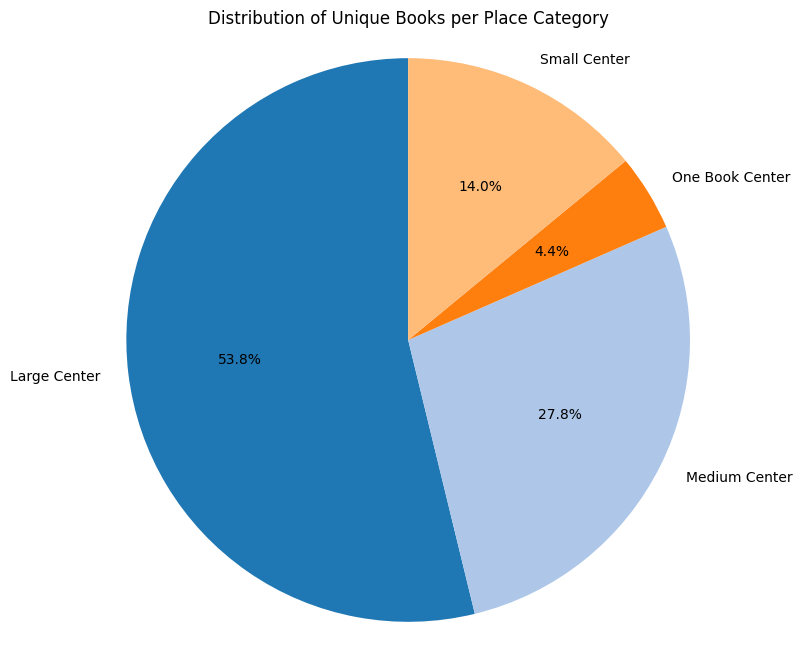

In [19]:
import matplotlib.pyplot as plt

# --- Step 1: Count unique books per place_category ---
books_per_category = df.groupby('place_category')['book'].nunique()

# --- Step 2: Create the pie chart ---
plt.figure(figsize=(8, 8))
plt.pie(
    books_per_category.values, 
    labels=books_per_category.index, 
    autopct='%1.1f%%',  # show percentages
    startangle=90,       # start from top
    colors=plt.cm.tab20.colors  # optional color palette
)
plt.title('Distribution of Unique Books per Place Category')
plt.axis('equal')  # Equal aspect ratio ensures pie is circular
plt.show()


📘 Number of Unique Books per Place Category and Total by Year Interval:

place_category  Large Center  Medium Center  One Book Center  Small Center  \
year_interval                                                                
1470-1489                  6              3                1             1   
1490-1509                 17             15                0             4   
1510-1529                 15              4                5             6   
1530-1549                 32              7                1             7   
1550-1569                 56             22                1             8   
1570-1589                 31             21                2             8   
1590-1609                 19             15                4             7   
1610-1629                  8              7                1             4   
1630-1650                  0              1                0             3   

place_category  Total  
year_interval          
1470-1489          1

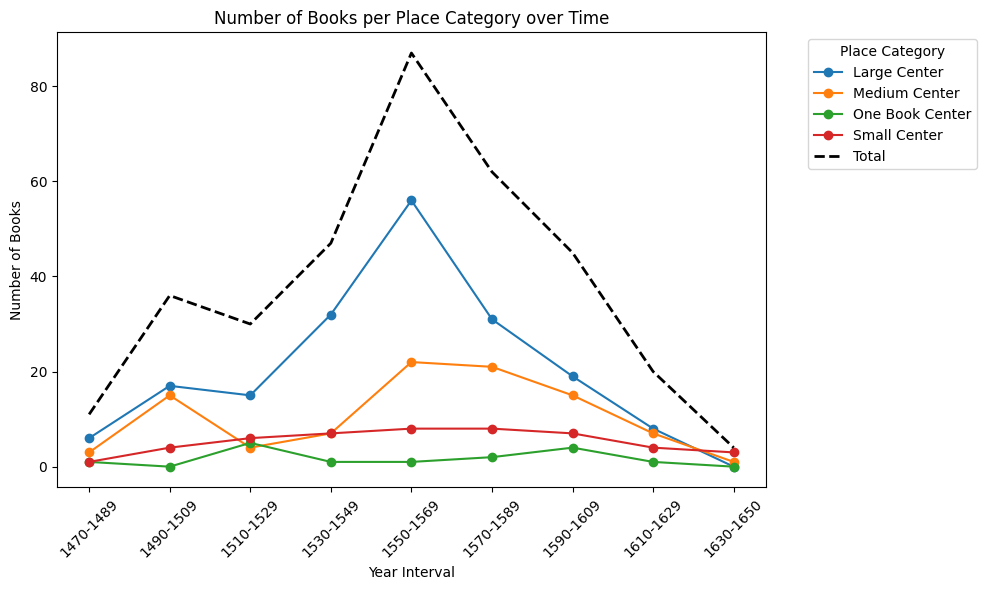

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Step 1: Count unique books per place_category per year_interval ---
books_by_cat = df.groupby(['year_interval', 'place_category'])['book'].nunique().unstack(fill_value=0)

# --- Step 2: Compute total number of books per year_interval ---
books_total = df.groupby('year_interval')['book'].nunique()

# --- Step 3: Add total as a column and print ---
books_by_cat['Total'] = books_total
print("📘 Number of Unique Books per Place Category and Total by Year Interval:\n")
print(books_by_cat)

# --- Step 4: Plot ---
plt.figure(figsize=(10, 6))

# Plot each place_category line
for col in books_by_cat.columns.drop('Total'):
    plt.plot(books_by_cat.index, books_by_cat[col], marker='o', label=col)

# Add total line (black dashed)
plt.plot(books_total.index, books_total.values, color='black', linestyle='--', linewidth=2, label='Total')

# --- Step 5: Formatting ---
plt.title('Number of Books per Place Category over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.legend(title='Place Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/place_cat_num_books.png', dpi=300, bbox_inches='tight')

plt.show()


📘 Number of Unique Books per Place (Large & Medium Centers) by Year Interval:

place          Antwerp  Cologne  Frankfurt (Main)  Leipzig  London  Lyon  \
year_interval                                                              
1470-1489          NaN      NaN               NaN      3.0     NaN   NaN   
1490-1509          NaN      6.0               NaN      9.0     NaN   NaN   
1510-1529          NaN      1.0               NaN      3.0     NaN   NaN   
1530-1549          4.0      NaN               3.0      NaN     NaN   NaN   
1550-1569          9.0      3.0               6.0      1.0     1.0   2.0   
1570-1589          8.0      1.0               1.0      NaN     4.0   7.0   
1590-1609          1.0      3.0               3.0      NaN     3.0   5.0   
1610-1629          NaN      1.0               NaN      3.0     1.0   2.0   
1630-1650          NaN      NaN               NaN      NaN     1.0   NaN   

place          Paris  Venice  Wittenberg  
year_interval                            

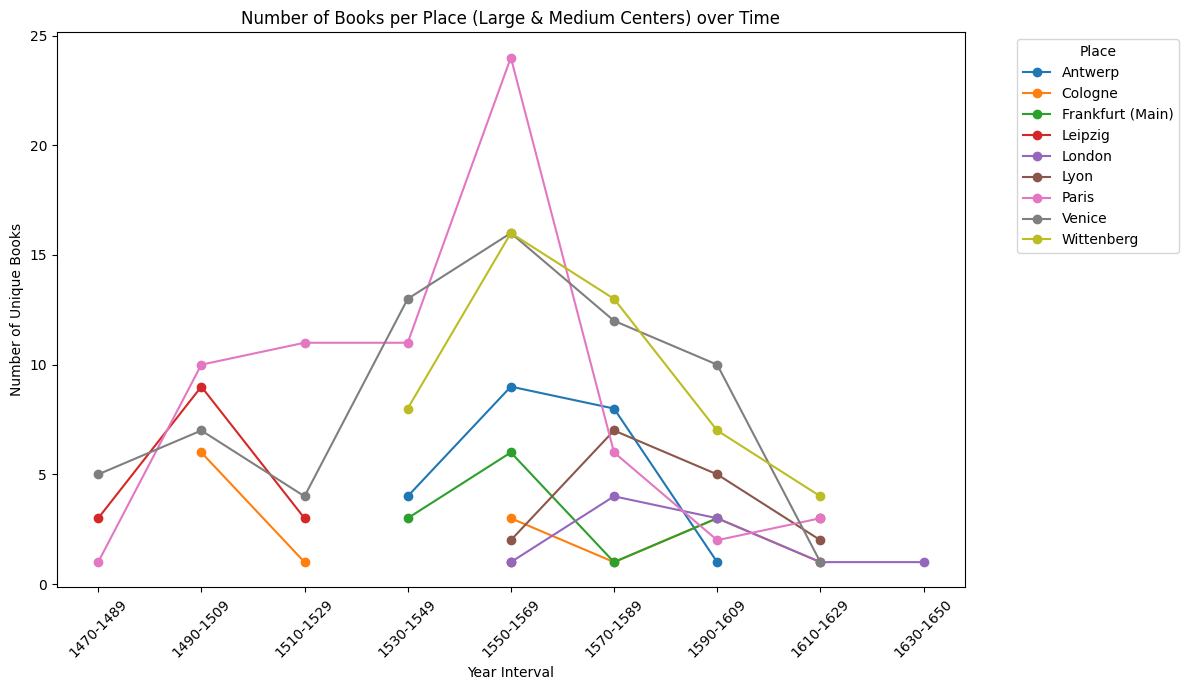

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Step 1: Filter only Large and Medium Centers ---
filtered_df = df[df['place_category'].isin(['Large Center', 'Medium Center'])]

# --- Step 2: Count unique books per place per year interval ---
books_by_place = (
    filtered_df.groupby(['year_interval', 'place'])['book']
    .nunique()
    .unstack(fill_value=0)
)

# --- Step 3: Replace zeros with np.nan so they don't get plotted ---
books_by_place = books_by_place.replace(0, np.nan)

# --- Step 4: Optionally remove places that are all NaN (never had any books) ---
books_by_place = books_by_place.dropna(axis=1, how='all')

# --- Step 5: Print summary ---
print("📘 Number of Unique Books per Place (Large & Medium Centers) by Year Interval:\n")
print(books_by_place)

# --- Step 6: Plot ---
plt.figure(figsize=(12, 7))

# Plot each place line (automatically skips NaN values)
for place in books_by_place.columns:
    plt.plot(books_by_place.index, books_by_place[place], marker='o', label=place)

# --- Step 7: Formatting ---
plt.title('Number of Books per Place (Large & Medium Centers) over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Place', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.savefig('/Users/nogashlomi/Desktop/place_cat_cities_num_books.png', dpi=300, bbox_inches='tight')


plt.show()
